<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Advanced Time Series: VAR Models
_Authors:_ Tim Book, Matt Brems, Noelle Brown (the dynamic trio)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from statsmodels.tsa.stattools import adfuller

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

We'll be using [U.S. Macroeconomic data](https://www.statsmodels.org/0.6.1/datasets/generated/macrodata.html) that is available via the `statsmodels` package. This is quarter-level data from 1959 to 2009.
- `year`: the year the data was measured.
- `quarter`: the quarter the data was measured.
- `realgdp`: real gross domestic product (in billions, in 2005 US dollars).
- `pop`: total population measured at the end of the quarter (includes all ages and overseas armed forces members).
- `unemp`: seasonally adjusted unemployment rate (in percent).

In [4]:
df = sm.datasets.macrodata.load_pandas().data
df.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [11]:
# Let's create a timeseries index from year and quarter
from statsmodels.tsa.base.datetools import dates_from_str

qtr = df['year'].astype(int).astype(str) + 'Q' + df['quarter'].astype(int).astype(str)
df.index = pd.to_datetime(dates_from_str(qtr))

df.drop(columns=['year', 'quarter'], inplace=True)

In [12]:
df.head()

,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959-03-31,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-06-30,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-09-30,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-12-31,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-03-31,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


# Topic 1: Generalized Least Squares
The main problem with OLS for time series data is that our "I" assumpiton (independence) is violated by definition - one data point directly depends on the one before it! We can create a **generalized least squares** estimate that eschews the "I" assumptions as follows:

$$y_t = \mathbf{x}_t^T\beta + w_t$$

where $w_t$ is an $\text{ARIMA}(p, q)$ process _instead_ of the usual $N(0, \sigma)$ assumption.

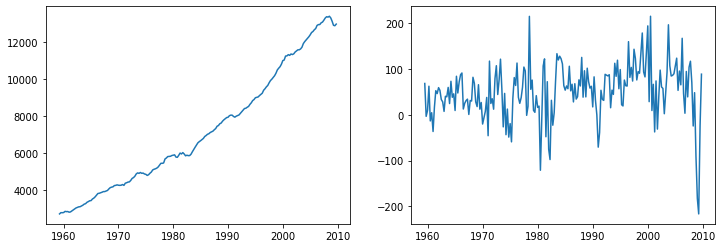

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(df.realgdp);
axs[1].plot(df.realgdp.diff());

In [42]:
y = df['realgdp']

xvars = ['realcons', 'realinv', 'realgovt', 'cpi', 'm1']
X = df[xvars]

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=20)

In [47]:
gls = ARIMA(y_train, exog=X_train, order=(2, 1, 2), freq='Q-DEC').fit()

/home/tim/.local/lib/python3.6/site-packages/statsmodels/tsa/base/tsa_model.py:162: ValueWarning: No frequency information was provided, so inferred frequency Q-DEC will be used.
  % freq, ValueWarning)
/home/tim/.local/lib/python3.6/site-packages/statsmodels/base/model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)


In [48]:
gls.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                realgdp   No. Observations:                  183
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -774.989
Date:                Mon, 22 Jul 2024   AIC                           1569.978
Time:                        11:37:21   BIC                           1602.018
Sample:                    03-31-1959   HQIC                          1582.967
                         - 09-30-2004                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
realcons       0.9885      0.043     23.248      0.000       0.905       1.072
realinv        1.0742      0.036     30.203      0.000       1.004       1.144
realgovt       0.6660      0.129      5.175      0.000       0.414       0.918
cpi           -0.2814      1.967     -0.143      0.886      -4.136       3.573
m1             0.1639      0.156      1.053      0.292      -0.141       0.469
ar.L1          1.8372      0.053     34.943      0.000       1.734       1.940
ar.L2         -0.9197      0.054    -17.021      0.000      -1.026      -0.814
ma.L1         -1.8030      0.052    -34.634      0.000      -1.905      -1.701
ma.L2          0.9386      0.049     19.232      0.000       0.843       1.034
sigma2       291.3321     27.679     10.525      0.000     237.082     345.582
===================================================================================
Ljung-Box (Q):                       24.31   Jarque-Bera (JB):                26.14
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               3.92   Skew:                             0.31
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [49]:
preds = gls.predict(start=X_test.index[0], end=X_test.index[-1], exog=X_test)

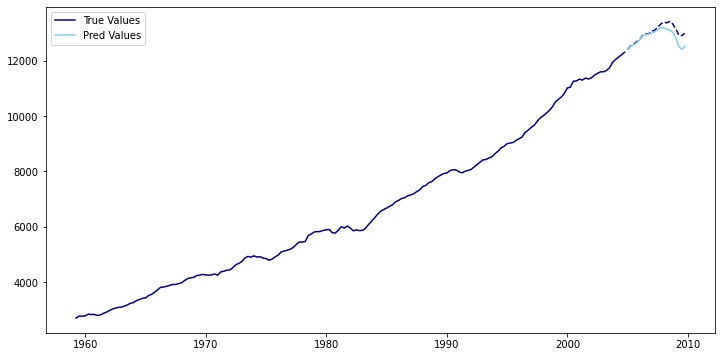

In [50]:
plt.figure(figsize=(12, 6))
plt.plot(y_train, c='navy', label='True Values')
plt.plot(y_test, c='navy', linestyle='dashed')
plt.plot(preds, c='skyblue', label='Pred Values')
plt.legend();

# Topic 2: GARCH Models

**Generalized autoregressive conditional heteroscedasticity (GARCH) models** can be used for time series data in which the series' variance changes over time and is susceptible to periods of large fluctuations. Because of this, it is particularly applicable to financial data.

In [68]:
# !pip install arch

import arch

SyntaxError: future feature annotations is not defined (__init__.py, line 1)

In [64]:
# Try this if you want!
# !pip install yfinance
# import yfinance as yf
# dis = yf.download('DIS')

dis = pd.read_csv('data/dis.csv').set_index('Date')
dis.index = pd.to_datetime(dis.index)
dis = dis[dis.index.year >= 1980]
dis.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-01-02,0.922275,0.924844,0.894016,0.894016,0.590325,7288799
1980-01-03,0.891447,0.891447,0.852911,0.883740,0.583540,9789762
1980-01-04,0.886309,0.899154,0.886309,0.894016,0.590325,4666194
1980-01-07,0.894016,0.901723,0.886309,0.896585,0.592021,5065180
1980-01-08,0.896585,0.924844,0.888878,0.914568,0.603896,5386315


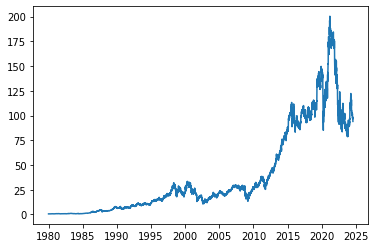

In [65]:
plt.plot(dis['Adj Close']);

In [66]:
dis.shape

(11231, 6)

<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Advanced Time Series: VAR Models
_Author: Matt Brems, Noelle Brown_

---

### Learning Objectives
_By the end of the lesson, students should be able to:_
- Describe univariate and multivariate time series.
- Identify the advantages of working with multivariate time series.
- Define VAR models.
- Understand and test for the assumptions of VAR models.
- Fit, generate predictions from, and evaluate VAR models.

In [1]:
# Imports
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split

## Extensions to ARIMA Model

As we discussed before, the ARIMA model is a very flexible model that can be extended in multiple ways.
- Seasonal ARIMA: An ARIMA model that can account for seasonal fluctuations and differences.
- ARIMA with eXogenous Predictors: An ARIMA model that can include eXogenous predictors (independent X variables).
- Vector ARIMA models: An ARIMA model that can handle multivariate time series.

## Multivariate Time Series Models

**Univariate** time series methods are those that deal with forecasting one variable into the future.

$$
\begin{eqnarray*}
Y^{(d)}_t = AR(p) + MA(q) + \text{seasonal component} + X_{1, t-1} + X_{2, t-1} + X_{3, t-1}
\end{eqnarray*}
$$

In this situation, we're taking three independent variables ($X_1$, $X_2$, $X_3$) and using them to predict $Y$. However, if $X_1$, $X_2$, $X_3$ are related to $Y$, does it make sense to forecast $X_1$, $X_2$, $X_3$ forward as well?

**Multivariate** time series methods are those that deal with forecasting multiple variables into the future.

Let's relabel $X_1$, $X_2$, $X_3$ as $Y_2$, $Y_3$, $Y_4$.

$$
\begin{eqnarray*}
\text{original series: } Y^{(d)}_{1,t} &=& AR(p) + MA(q) + \text{seasonal component} + Y_{2, t-1} + Y_{3, t-1} + Y_{4, t-1} \\
\\
Y^{(d)}_{2,t} &=& AR(p) + MA(q) + \text{seasonal component} + Y_{1, t-1} + Y_{3, t-1} + Y_{4, t-1} \\
\\
Y^{(d)}_{3,t} &=& AR(p) + MA(q) + \text{seasonal component} + Y_{1, t-1} + Y_{2, t-1} + Y_{4, t-1} \\
\\
Y^
{(d)}_{4,t} &=& AR(p) + MA(q) + \text{seasonal component} + Y_{1, t-1} + Y_{2, t-1} + Y_{3, t-1} \\
\end{eqnarray*}
$$

This makes the most sense as a strategy when our variables are all related. 
- $Y_1$ is related to $Y_2$, $Y_3$, $Y_4$,
- $Y_2$ is related to $Y_1$, $Y_3$, $Y_4$,
- and so on.

The most common method of tackling this is to use VAR models.

## VAR Time Series Models

VAR time series models are **vector autoregressive models**.
- Rather than regressing one time series $Y_t$ on lagged versions of itself and on lagged versions of independent variables $X$, we will take all of our variables $Y_{1,t}, Y_{2,t}, Y_{3,t}, \ldots$ and regress them on one another simultaneously.
- This allows us to forecast forward many variables simultaneously.

<details><summary>What are examples of variables we may want to forecast forward together?</summary>
    
_(Answers may vary.)_

- Prevalence of multiple pollutants (like chemicals from factories).
- Exchange rates between countries. (e.g. USD to EUR, EUR to CHF, CHF to GBP, GBP to USD.)
- Macroeconomic indices (like GDP and unemployment rate) that may influence one another.
</details>

In [2]:
# Import VAR
from statsmodels.tsa.api import VAR

In [3]:
# Load up the macroeconomic data.
df = sm.datasets.macrodata.load_pandas().data

> We'll be using [U.S. Macroeconomic data](https://www.statsmodels.org/0.6.1/datasets/generated/macrodata.html) that is available via the `statsmodels` package. This is quarter-level data from 1959 to 2009.
- `year`: the year the data was measured.
- `quarter`: the quarter the data was measured.
- `realgdp`: real gross domestic product (in billions, in 2005 US dollars).
- `pop`: total population measured at the end of the quarter (includes all ages and overseas armed forces members).
- `unemp`: seasonally adjusted unemployment rate (in percent).

In [4]:
df.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [5]:
# Create an array called "dates" based on "year" and "quarter."
dates = df[['year', 'quarter']].astype(int).astype(str)

# Create a vector called "quarterly" combining year and quarter together.
quarterly = dates["year"] + "Q" + dates["quarter"]

# Import dates_from_str and convert "quarterly" into dates.
from statsmodels.tsa.base.datetools import dates_from_str
quarterly = dates_from_str(quarterly)

In [6]:
# Select only the realgdp, pop, unemp columns.
df = df[['realgdp','pop','unemp']]

# Set index to be "quarterly."
df.index = pd.DatetimeIndex(quarterly)

df.head()

,realgdp,pop,unemp
1959-03-31,2710.349,177.146,5.8
1959-06-30,2778.801,177.830,5.1
1959-09-30,2775.488,178.657,5.3
1959-12-31,2785.204,179.386,5.6
1960-03-31,2847.699,180.007,5.2


In [7]:
# Code modified from code written by Matthew Garton.

def plot_series(df, cols=None, title='Title', xlab=None, ylab=None, steps=1):
    
    # Set figure size to be (18, 9).
    plt.figure(figsize=(18,9))
    legend_list = []
    
    # Iterate through each column name.
    for col in cols:
            
        # Generate a line plot of the column name.
        # You only have to specify Y, since our
        # index will be a datetime index.
        plt.plot(df[col])
        legend_list.append(col)
        
    # Generate title and labels.
    plt.title(title, fontsize=26)
    plt.xlabel(xlab, fontsize=20)
    plt.ylabel(ylab, fontsize=20)
    
    # Enlarge tick marks.
    plt.yticks(fontsize=18)
    plt.xticks(df.index[0::steps], fontsize=18)
    
    plt.legend(legend_list);

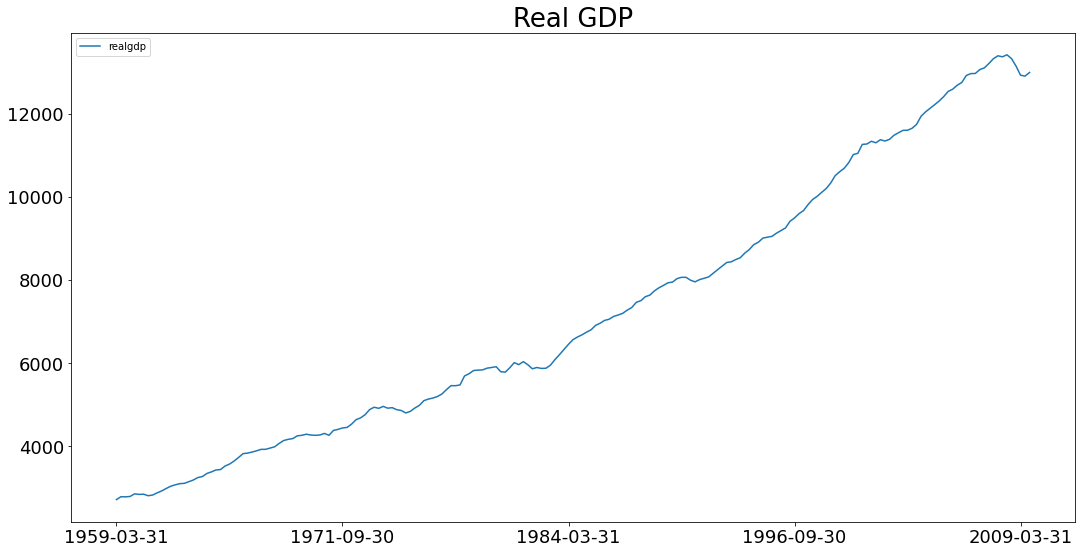

In [8]:
# Plot our real GDP data.
plot_series(df,
            ['realgdp'],
            title="Real GDP",
            steps=50)

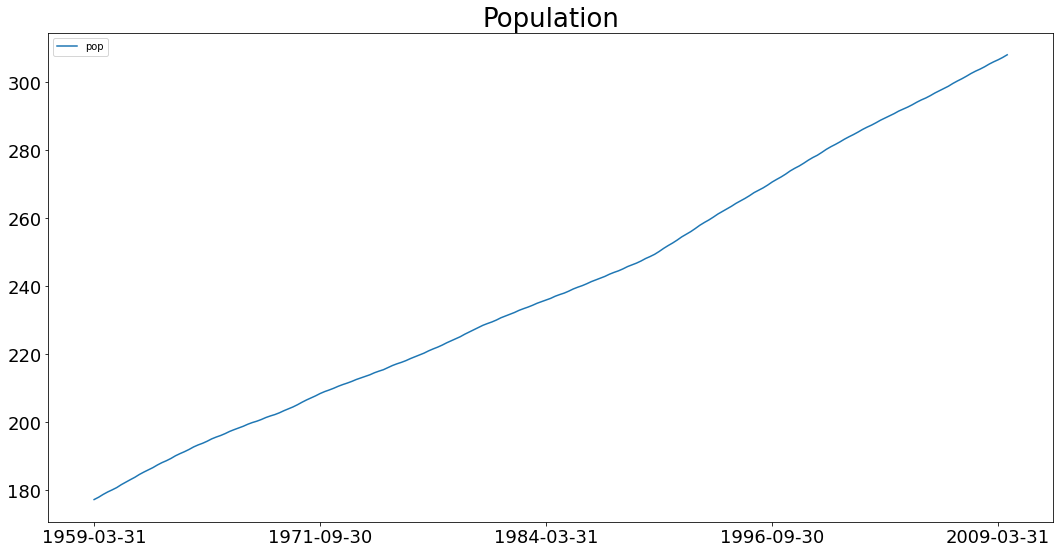

In [9]:
# Plot our population data.
plot_series(df,
            ['pop'],
            title="Population",
            steps=50)

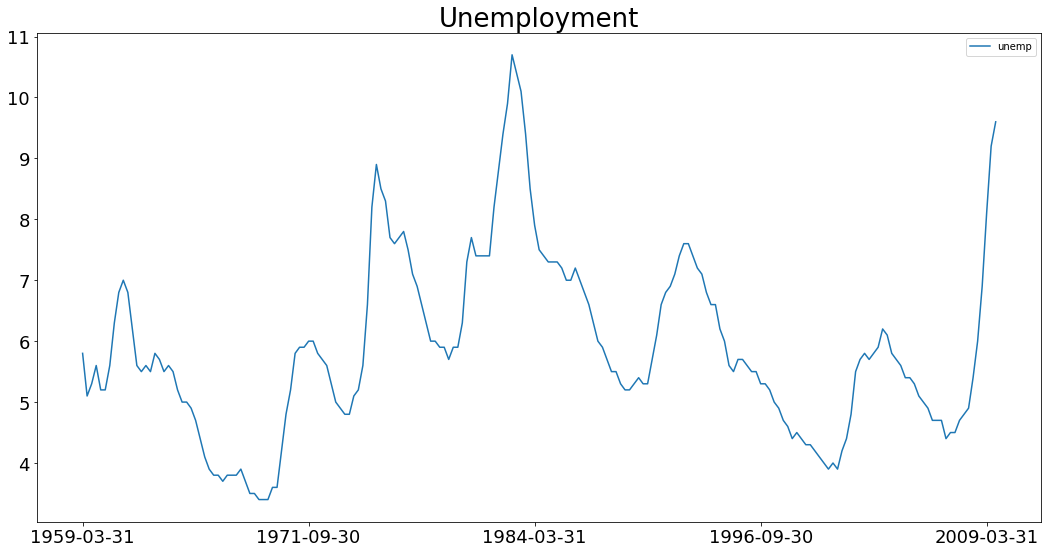

In [10]:
# Plot our unemployment data.
plot_series(df,
            ['unemp'],
            title="Unemployment",
            steps=50)

### Model Fitting Process
1. Confirm stationarity of the data.
2. Train/test split.
3. Determine correct lag order $p$.
4. Fit model.
5. Generate forecasts.
6. Evaluate model and forecasts (if possible).

#### 1. Confirm stationarity of the data.
Vector autoregressive models require stationarity in order for us to fit them!

<details><summary>How would you describe stationarity?</summary>

- When our time series does not have systematic changes over time.
- Constant mean, correlation that only depends on lag (and not point in time).
</details>

<details><summary>What do we use to check whether or not a time series is stationary?</summary>

- Augmented Dickey-Fuller test!
</details>

In [11]:
# Code written by Joseph Nelson.
# Improved by Hovanes Gasparian

def interpret_dftest(dftest):
    dfoutput = pd.Series(dftest[0:3], index=['Test Statistic','p-value', 'Lag Used'])
    return dfoutput

In [12]:
# Run ADF test on the original Real GDP data.
interpret_dftest(adfuller(df['realgdp']))

Test Statistic     1.750463
p-value            0.998246
Lag Used          12.000000
dtype: float64

<details><summary>Based on the results here, what action should we take?</summary>

- Difference our data.
</details>

In [13]:
# Run ADF test on the first-differenced Real GDP data.
interpret_dftest(adfuller(df['realgdp'].diff(1).dropna()))

Test Statistic   -6.305696e+00
p-value           3.327882e-08
Lag Used          1.000000e+00
dtype: float64

In [14]:
# Create first difference column.
df['first_diff_realgdp'] = df['realgdp'].diff(1)

In [15]:
df.head()

,realgdp,pop,unemp,first_diff_realgdp
1959-03-31,2710.349,177.146,5.8,NaN
1959-06-30,2778.801,177.830,5.1,68.452
1959-09-30,2775.488,178.657,5.3,-3.313
1959-12-31,2785.204,179.386,5.6,9.716
1960-03-31,2847.699,180.007,5.2,62.495


Assuming $\alpha=0.01$, take two minutes to achieve stationarity for `pop` and `unemp`. If needed, create the columns we want to model.

In [16]:
# Run ADF test.
interpret_dftest(adfuller(df['pop']))

Test Statistic     1.730647
p-value            0.998201
Lag Used          15.000000
dtype: float64

In [17]:
# Run ADF test.
interpret_dftest(adfuller(df['pop'].diff(1).dropna()))

Test Statistic    -1.615825
p-value            0.474919
Lag Used          14.000000
dtype: float64

In [18]:
# Run ADF test.
interpret_dftest(adfuller(df['pop'].diff(1).diff(1).dropna()))

Test Statistic    -4.397672
p-value            0.000300
Lag Used          13.000000
dtype: float64

In [19]:
# Create second difference column.
df['second_diff_pop'] = df['pop'].diff(1).diff(1)

In [20]:
# Run ADF test.
interpret_dftest(adfuller(df['unemp']))

Test Statistic   -2.536458
p-value           0.106854
Lag Used          9.000000
dtype: float64

In [21]:
# Run ADF test.
interpret_dftest(adfuller(df['unemp'].diff(1).dropna()))

Test Statistic   -4.168475
p-value           0.000745
Lag Used          8.000000
dtype: float64

In [22]:
# Create first difference column.
df['first_diff_unemp'] = df['unemp'].diff(1)

#### 2. Train/test split.

In [23]:
# Subset our data.
df = df[['first_diff_realgdp', 'second_diff_pop', 'first_diff_unemp']]

# Let's get rid of rows containing missing values.
df.dropna(inplace = True)

In [24]:
# What am I missing?

train, test = train_test_split(df,
                               test_size = 0.25,
                               shuffle = False)

#### 3. Determine correct lag order $p$.

We can check out autocorrelation plots and partial autocorrelation plots to attempt to figure out how many previous values of **each variable** we want in our model.

Suppose I select $p=1$.

$$
\begin{eqnarray*}
\Large Y^{(d)}_{1,t} &=& \Large \beta_0 + \beta_1Y^{(d)}_{1,t-1} + \beta_2Y^{(d)}_{2,t-1} + \beta_3Y^{(d)}_{3,t-1} \\
\\
\Large Y^{(d)}_{2,t} &=& \Large \gamma_0 + \gamma_1Y^{(d)}_{1,t-1} + \gamma_2Y^{(d)}_{2,t-1} + \gamma_3Y^{(d)}_{3,t-1} \\
\\
\Large Y^{(d)}_{3,t} &=& \Large \delta_0 + \delta_1Y^{(d)}_{1,t-1} + \delta_2Y^{(d)}_{2,t-1} + \delta_3Y^{(d)}_{3,t-1}
\\
\end{eqnarray*}
$$

Suppose I select $p=2$.

$$
\begin{eqnarray*}
\Large Y^{(d)}_{1,t} &=& \Large \beta_0 + \beta_1Y^{(d)}_{1,t-1} + \beta_2Y^{(d)}_{1,t-2} + \beta_3Y^{(d)}_{2,t-1} + \beta_4Y^{(d)}_{2,t-2} + \beta_5Y^{(d)}_{3,t-1} + \beta_6Y^{(d)}_{3,t-2} \\
\\
\Large Y^{(d)}_{2,t} &=& \Large \gamma_0 + \gamma_1Y^{(d)}_{1,t-1} + \gamma_2Y^{(d)}_{1,t-2} + \gamma_3Y^{(d)}_{2,t-1} + \gamma_4Y^{(d)}_{2,t-2} + \gamma_5Y^{(d)}_{3,t-1} + \gamma_6Y^{(d)}_{3,t-2} \\
\\
\Large Y^{(d)}_{3,t} &=& \Large \delta_0 + \delta_1Y^{(d)}_{1,t-1} + \delta_2Y^{(d)}_{1,t-2} + \delta_3Y^{(d)}_{2,t-1} + \delta_4Y^{(d)}_{2,t-2} + \delta_5Y^{(d)}_{3,t-1} + \delta_6Y^{(d)}_{3,t-2}
\\
\end{eqnarray*}
$$

We can automate the selection of $p$ using a metric called the Akaike information criterion, or the AIC.

##### AIC

The AIC is a metric that is commonly used for time series models or in more "statistics-oriented" fields.
- Recall that models are just simplifications of reality. AIC attempts to measure how much information we lose when we simplify reality with a model.
- The lower the AIC, the better!
- More details can be found at the [Wikipedia page](https://en.wikipedia.org/wiki/Akaike_information_criterion).

We can actually find a good value of $p$ at the time of fitting our model!

#### 4. Fit model.

In [25]:
# Instantiate a VAR model. Remember that we pass
# our data in during instantiation in statsmodels!
model = VAR(train, freq='Q-DEC')

In [26]:
# Fit our model and use AIC to select the value of p.

ts_model = model.fit(maxlags=15, # what is the largest possible value of p?
                     ic='aic')   # what "information criterion" (ic) will we use to decide what's "best?"

In [27]:
# What is the order of our autoregressive model? 
ts_model.k_ar

4

In [28]:
# Check out the summary of our model!
ts_model.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 27, Nov, 2022
Time:                     20:17:33
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  -0.996910
Nobs:                     146.000    HQIC:                  -1.47007
Log likelihood:          -451.540    FPE:                   0.166546
AIC:                     -1.79390    Det(Omega_mle):        0.128944
--------------------------------------------------------------------
Results for equation first_diff_realgdp
                           coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------
const                        23.250741        10.473768            2.220           0.026
L1.first_diff_realgdp         0.103736         0.100731            1.030           0.303
L1.second_diff_

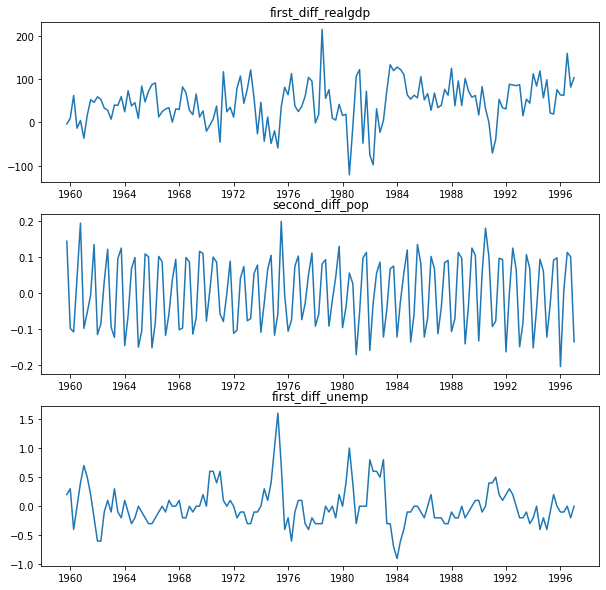

In [29]:
# Plot our training data.
ts_model.plot();

#### 5. Generate forecasts.

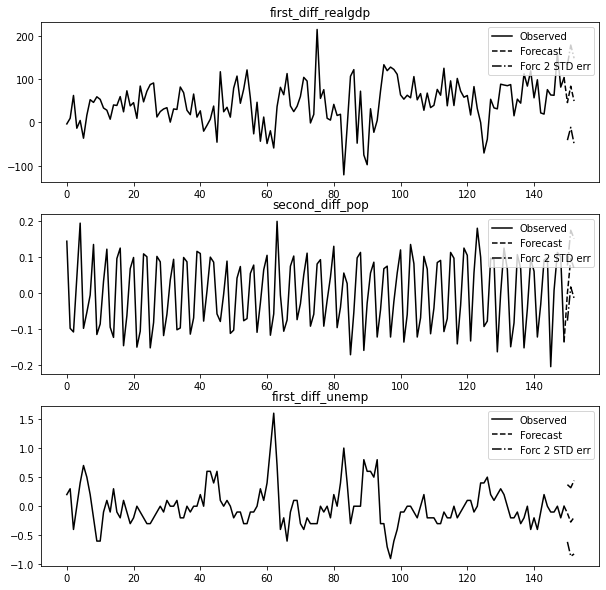

In [30]:
# Plot the forecast looking 3 steps ahead.
ts_model.plot_forecast(3);

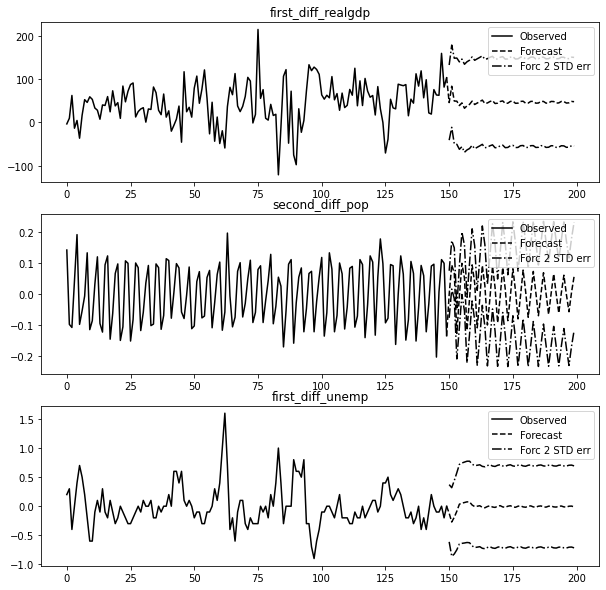

In [31]:
# Plot the forecast looking 50 steps ahead.
ts_model.plot_forecast(50);

In [32]:
# Generate a forecast one step ahead.
ts_model.forecast(train.values, 1)

array([[ 4.60133719e+01, -4.35975472e-04, -1.21245774e-01]])

In [33]:
# Generate a forecast five steps ahead.
ts_model.forecast(train.values, 5)

array([[ 4.60133719e+01, -4.35975472e-04, -1.21245774e-01],
       [ 8.39109946e+01,  9.49079885e-02, -2.71839880e-01],
       [ 4.96001022e+01,  6.76670319e-02, -1.90197121e-01],
       [ 4.92837943e+01, -1.27157164e-01, -8.64169194e-02],
       [ 3.90626298e+01, -7.29535302e-03,  3.46047233e-02]])

In [34]:
# Generate a forecast that matches our testing set.
ts_model.forecast(train.values, len(test))

array([[ 4.60133719e+01, -4.35975472e-04, -1.21245774e-01],
       [ 8.39109946e+01,  9.49079885e-02, -2.71839880e-01],
       [ 4.96001022e+01,  6.76670319e-02, -1.90197121e-01],
       [ 4.92837943e+01, -1.27157164e-01, -8.64169194e-02],
       [ 3.90626298e+01, -7.29535302e-03,  3.46047233e-02],
       [ 4.53110064e+01,  9.99029602e-02,  5.21223486e-02],
       [ 3.28672292e+01,  5.15480699e-02,  6.32787030e-02],
       [ 3.84698459e+01, -1.16634756e-01,  7.49054219e-02],
       [ 4.19244233e+01, -1.34473806e-02,  7.28128870e-02],
       [ 4.94275630e+01,  9.48906389e-02,  2.08012675e-02],
       [ 4.15626509e+01,  3.62083154e-02, -6.71500060e-03],
       [ 4.49504704e+01, -1.09126582e-01, -8.88058034e-05],
       [ 4.82000442e+01, -1.44566394e-02,  8.25916689e-03],
       [ 5.17925411e+01,  9.24596738e-02, -1.92757334e-02],
       [ 4.38708771e+01,  2.79263106e-02, -2.68906544e-02],
       [ 4.51195394e+01, -9.99923189e-02, -5.62392018e-03],
       [ 4.84578553e+01, -1.21217648e-02

In [35]:
# See the values of our test set.
test.values

array([[ 7.37770e+01, -5.60000e-02, -1.00000e-01],
       [ 1.43316e+02,  1.06000e-01, -2.00000e-01],
       [ 1.23121e+02,  1.11000e-01, -1.00000e-01],
       [ 7.62020e+01, -1.66000e-01, -2.00000e-01],
       [ 9.45510e+01, -9.60000e-02, -1.00000e-01],
       [ 9.08520e+01,  1.33000e-01, -2.00000e-01],
       [ 1.34510e+02,  7.70000e-02,  1.00000e-01],
       [ 1.78788e+02, -1.01000e-01, -1.00000e-01],
       [ 9.36040e+01, -1.26000e-01, -1.00000e-01],
       [ 8.28700e+01,  1.83000e-01,  0.00000e+00],
       [ 1.35865e+02,  6.40000e-02, -1.00000e-01],
       [ 1.94340e+02, -1.35000e-01, -1.00000e-01],
       [ 2.87900e+01, -9.60000e-02, -1.00000e-01],
       [ 2.15410e+02,  5.50000e-02, -1.00000e-01],
       [ 9.41300e+00,  7.30000e-02,  1.00000e-01],
       [ 6.66770e+01, -9.50000e-02, -1.00000e-01],
       [-3.73730e+01, -6.00000e-02,  3.00000e-01],
       [ 7.40800e+01,  6.70000e-02,  2.00000e-01],
       [-3.11760e+01,  6.30000e-02,  4.00000e-01],
       [ 4.00530e+01, -9.90000e

#### 6. Evaluate model (and forecasts, if possible).

In [36]:
# We'll use MSE
from sklearn.metrics import mean_squared_error

In [37]:
# Save forecasted values
forecast = ts_model.forecast(train.values, len(test))

In [38]:
# Loop through columns and get MSE for each
for i in range(test.shape[1]):
    print(f'The test MSE on the {test.columns[i]} data is: {round(mean_squared_error(test.values[:, i], forecast[:, i]), 4)}')

The test MSE on the first_diff_realgdp data is: 6943.76
The test MSE on the second_diff_pop data is: 0.0033
The test MSE on the first_diff_unemp data is: 0.1159
